In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images Shape :", x_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Images Shape :", x_test.shape)
print("Testing Labels Shape :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2195s 13us/step
Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)
Testing Images Shape : (10000, 32, 32, 3)
Testing Labels Shape : (10000, 1)


In [3]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

print(class_names)

['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


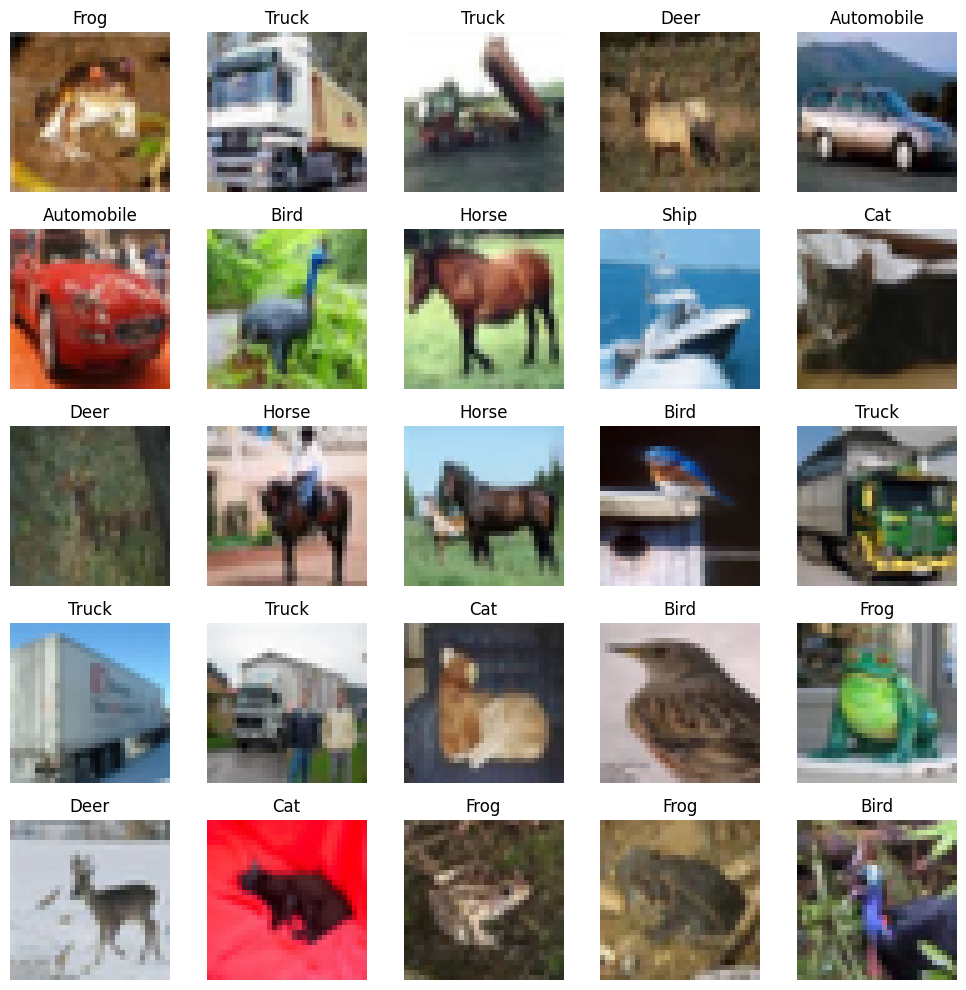

In [4]:
# Display the first 25 images from the training dataset

plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.savefig("sample_images.eps", format="eps", bbox_inches="tight")
plt.show()

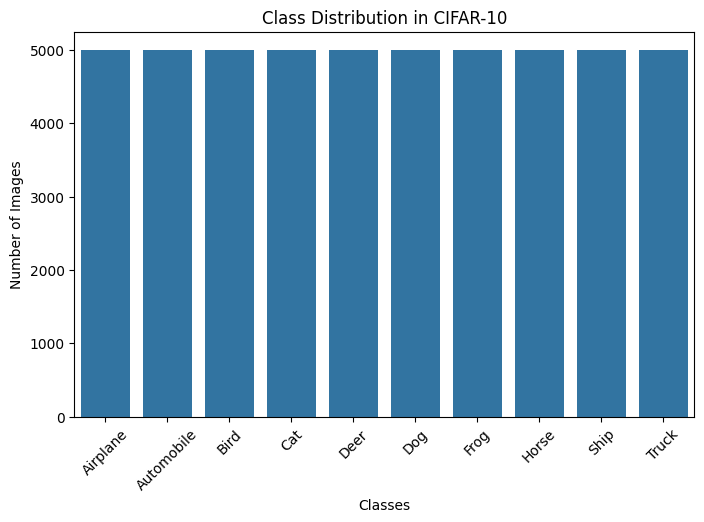

In [5]:
# Count the number of images in each class
labels = y_train.flatten()

unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(8,5))
sns.barplot(x=class_names, y=counts)

plt.xticks(rotation=45)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution in CIFAR-10")
plt.savefig("class_distribution.eps", format="eps", bbox_inches="tight")
plt.show()

In [6]:
# Normalize the image pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Training Data Range:")
print("Minimum Pixel Value:", x_train.min())
print("Maximum Pixel Value:", x_train.max())

Training Data Range:
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [7]:
# Convert labels to one-hot encoding
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print("Original Label:", y_train[0])
print("One-Hot Encoded Label:")
print(y_train_encoded[0])

Original Label: [6]
One-Hot Encoded Label:
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [8]:
print("Training Images :", x_train.shape)
print("Training Labels :", y_train_encoded.shape)

print("Testing Images :", x_test.shape)
print("Testing Labels :", y_test_encoded.shape)

Training Images : (50000, 32, 32, 3)
Training Labels : (50000, 10)
Testing Images : (10000, 32, 32, 3)
Testing Labels : (10000, 10)


#Task 2

In [9]:
# Task 2: Kernel Size Comparison

sample_image = x_train[0:1]

print("Input Image Shape:", sample_image.shape)

# Store outputs for visualization
output_3x3 = None
output_5x5 = None
output_7x7 = None

kernels = [(3, 3), (5, 5), (7, 7)]

for kernel in kernels:

    conv_layer = Conv2D(
        filters=32,
        kernel_size=kernel,
        strides=(1, 1),
        padding='valid',
        activation='relu'
    )

    output = conv_layer(sample_image)

    print(
        f"{kernel} Kernel Feature Map Shape:",
        output.shape
    )

    if kernel == (3, 3):
        output_3x3 = output

    elif kernel == (5, 5):
        output_5x5 = output

    elif kernel == (7, 7):
        output_7x7 = output

Input Image Shape: (1, 32, 32, 3)
(3, 3) Kernel Feature Map Shape: (1, 30, 30, 32)
(5, 5) Kernel Feature Map Shape: (1, 28, 28, 32)
(7, 7) Kernel Feature Map Shape: (1, 26, 26, 32)


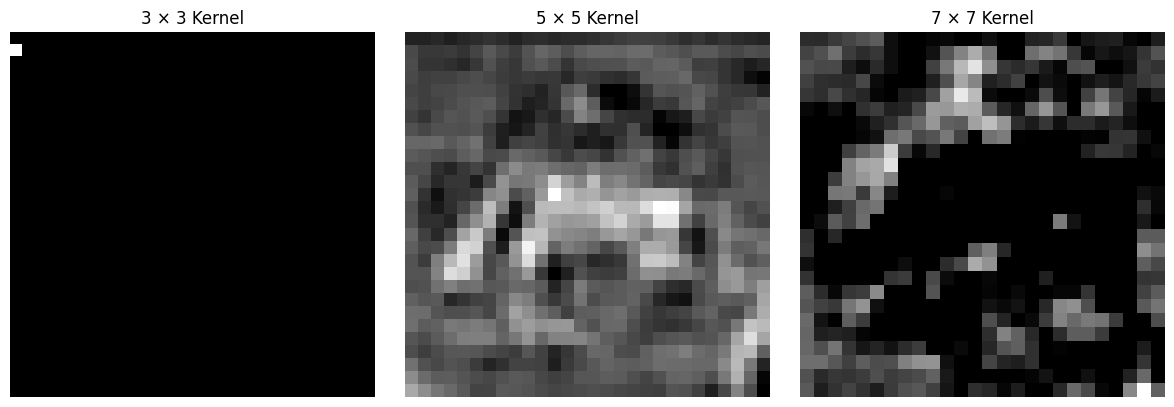

In [10]:
# Displaying one feature map from each kernel size
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(output_3x3[0, :, :, 0], cmap='gray')
plt.title("3 × 3 Kernel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(output_5x5[0, :, :, 0], cmap='gray')
plt.title("5 × 5 Kernel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(output_7x7[0, :, :, 0], cmap='gray')
plt.title("7 × 7 Kernel")
plt.axis("off")

plt.tight_layout()
plt.savefig("kernel_size_comparison.eps", format="eps", bbox_inches="tight")
plt.show()

# Task 3

In [11]:
sample_image = x_train[0:1]

# Case 1: Stride = 1, Padding = Same
conv_stride1_same = Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding='same',
    activation='relu'
)

output_stride1_same = conv_stride1_same(sample_image)


# Case 2: Stride = 2, Padding = Same
conv_stride2_same = Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=(2, 2),
    padding='same',
    activation='relu'
)

output_stride2_same = conv_stride2_same(sample_image)


# Case 3: Stride = 1, Padding = Valid
conv_stride1_valid = Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=(1, 1),
    padding='valid',
    activation='relu'
)

output_stride1_valid = conv_stride1_valid(sample_image)


# Case 4: Stride = 2, Padding = Valid
conv_stride2_valid = Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=(2, 2),
    padding='valid',
    activation='relu'
)

output_stride2_valid = conv_stride2_valid(sample_image)


print("Input Shape:", sample_image.shape)

print("\nStride = 1, Padding = Same:")
print(output_stride1_same.shape)

print("\nStride = 2, Padding = Same:")
print(output_stride2_same.shape)

print("\nStride = 1, Padding = Valid:")
print(output_stride1_valid.shape)

print("\nStride = 2, Padding = Valid:")
print(output_stride2_valid.shape)

Input Shape: (1, 32, 32, 3)

Stride = 1, Padding = Same:
(1, 32, 32, 32)

Stride = 2, Padding = Same:
(1, 16, 16, 32)

Stride = 1, Padding = Valid:
(1, 30, 30, 32)

Stride = 2, Padding = Valid:
(1, 15, 15, 32)


# Task 5


In [12]:
sample_image = x_train[0:1]

# Max Pooling
max_pool = MaxPooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)
max_pool_output = max_pool(sample_image)


# Average Pooling
average_pool = AveragePooling2D(
    pool_size=(2, 2),
    strides=(2, 2)
)
average_pool_output = average_pool(sample_image)


print("Input Shape:", sample_image.shape)
print("Max Pooling Output Shape:", max_pool_output.shape)
print("Average Pooling Output Shape:", average_pool_output.shape)

Input Shape: (1, 32, 32, 3)
Max Pooling Output Shape: (1, 16, 16, 3)
Average Pooling Output Shape: (1, 16, 16, 3)


In [13]:
# Task 5: Accuracy Comparison

def build_pooling_model(pooling_type):

    model = Sequential()

    model.add(Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        input_shape=(32, 32, 3)
    ))

    if pooling_type == 'max':
        model.add(MaxPooling2D(pool_size=(2, 2)))
    else:
        model.add(AveragePooling2D(pool_size=(2, 2)))

    model.add(Flatten())

    model.add(Dense(
        10,
        activation='softmax'
    ))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [14]:
# Max Pooling Model

max_model = build_pooling_model('max')

max_history = max_model.fit(
    x_train,
    y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

max_loss, max_accuracy = max_model.evaluate(
    x_test,
    y_test_encoded,
    verbose=0
)

print("Max Pooling Test Accuracy:", max_accuracy)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4706 - loss: 1.5129 - val_accuracy: 0.5454 - val_loss: 1.3159
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5752 - loss: 1.2224 - val_accuracy: 0.5655 - val_loss: 1.2628
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6154 - loss: 1.1157 - val_accuracy: 0.6153 - val_loss: 1.1412
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6429 - loss: 1.0383 - val_accuracy: 0.6218 - val_loss: 1.1083
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6623 - loss: 0.9800 - val_accuracy: 0.6286 - val_loss: 1.0818
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6816 - loss: 0.9305 - val_accuracy: 0.6269 - val_loss: 1.0914
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6951 - loss: 0.8873 - val_accuracy: 0.6341 - val_loss: 1.0799
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7060 - loss: 0.8506 - 

In [15]:
# Average Pooling Model

average_model = build_pooling_model('average')

average_history = average_model.fit(
    x_train,
    y_train_encoded,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

average_loss, average_accuracy = average_model.evaluate(
    x_test,
    y_test_encoded,
    verbose=0
)

print("Average Pooling Test Accuracy:", average_accuracy)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4477 - loss: 1.5679 - val_accuracy: 0.5239 - val_loss: 1.3658
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5515 - loss: 1.2840 - val_accuracy: 0.5585 - val_loss: 1.2802
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5785 - loss: 1.2103 - val_accuracy: 0.5654 - val_loss: 1.2505
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5970 - loss: 1.1562 - val_accuracy: 0.5566 - val_loss: 1.2758
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6130 - loss: 1.1152 - val_accuracy: 0.5805 - val_loss: 1.2020
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6233 - loss: 1.0806 - val_accuracy: 0.5750 - val_loss: 1.2288
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6381 - loss: 1.0461 - val_accuracy: 0.5910 - val_loss: 1.1943
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6486 - loss: 1.0111 - 

In [16]:
# Compare Pooling Accuracy

print("Max Pooling Accuracy    :", max_accuracy)
print("Average Pooling Accuracy:", average_accuracy)

Max Pooling Accuracy    : 0.6391000151634216
Average Pooling Accuracy: 0.5968999862670898


# Task 6

In [17]:
model = Sequential()

# First Convolution Block
model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation='relu',
    padding='same',
    input_shape=(32, 32, 3)
))

model.add(MaxPooling2D(
    pool_size=(2, 2)
))

# Second Convolution Block
model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation='relu',
    padding='same'
))

model.add(MaxPooling2D(
    pool_size=(2, 2)
))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(
    128,
    activation='relu'
))

# Output Layer
model.add(Dense(
    10,
    activation='softmax'
))

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=0
)

history = model.fit(
    x_train,
    y_train_encoded,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/20
1242/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3919 - loss: 1.6659
Epoch 1: val_loss improved from None to 1.16020, saving model to best_cnn.weights.h5

Epoch 1: finished saving model to best_cnn.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4900 - loss: 1.4206 - val_accuracy: 0.5935 - val_loss: 1.1602
Epoch 2/20
1242/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6218 - loss: 1.0782
Epoch 2: val_loss improved from 1.16020 to 1.00636, saving model to best_cnn.weights.h5

Epoch 2: finished saving model to best_cnn.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6357 - loss: 1.0438 - val_accuracy: 0.6495 - val_loss: 1.0064
Epoch 3/20
1245/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6854 - loss: 0.9024
Epoch 3: val_loss improved from 1.00636 to 0.99122, saving model to best_cnn.weights.h5

Epoch 3: finished saving model to best_cnn.weights.h5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6878 - loss: 0.

In [20]:
# Load the best model weights
model.load_weights("best_cnn.weights.h5")
print("Best model weights loaded successfully.")

Best model weights loaded successfully.


In [40]:
# Evaluate the same best model on both training and testing data

train_loss, train_accuracy = model.evaluate(
    x_train,
    y_train_encoded,
    verbose=0
)

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_encoded,
    verbose=0
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy: 0.7616000175476074
Testing Accuracy : 0.6973999738693237


In [22]:
# Task 4: Feature Map Visualization

feature_model = tf.keras.Model(
    inputs=model.inputs[0],
    outputs=model.layers[0].output
)

sample_image = x_test[0:1]
feature_maps = feature_model.predict(
    sample_image,
    verbose=0
)

print("Feature Maps Shape:", feature_maps.shape)

Feature Maps Shape: (1, 32, 32, 32)


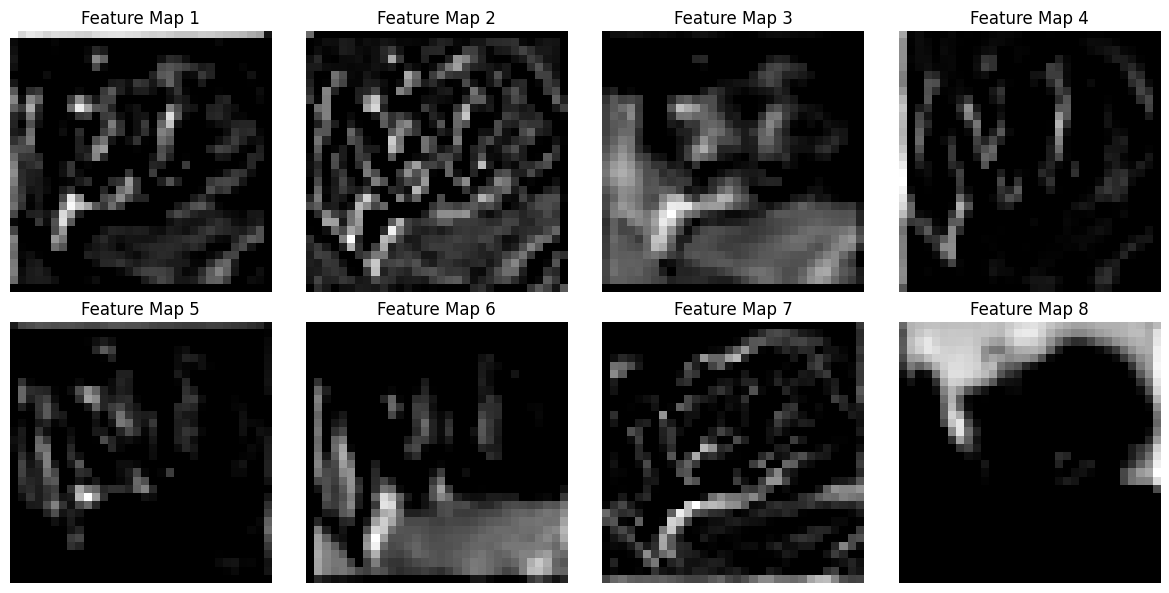

In [23]:
plt.figure(figsize=(12, 6))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        feature_maps[0, :, :, i],
        cmap='gray'
    )

    plt.title("Feature Map " + str(i + 1))
    plt.axis("off")

plt.tight_layout()
plt.savefig("feature_maps.eps", format="eps", bbox_inches="tight")
plt.show()

# Task 7

In [24]:
#Generate predictions
predictions = model.predict(
    x_test,
    verbose=0
)
predicted_classes = np.argmax(
    predictions,
    axis=1
)
true_classes = y_test.flatten()

In [25]:
# Classification Report
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

    Airplane       0.68      0.81      0.74      1000
  Automobile       0.78      0.86      0.82      1000
        Bird       0.64      0.49      0.56      1000
         Cat       0.58      0.40      0.48      1000
        Deer       0.64      0.66      0.65      1000
         Dog       0.56      0.65      0.61      1000
        Frog       0.76      0.75      0.76      1000
       Horse       0.69      0.80      0.74      1000
        Ship       0.82      0.79      0.81      1000
       Truck       0.78      0.76      0.77      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.69     10000
weighted avg       0.70      0.70      0.69     10000



In [26]:
# Overall Accuracy
accuracy = accuracy_score(
    true_classes,
    predicted_classes
)

print("Overall Accuracy:", accuracy)

Overall Accuracy: 0.6974


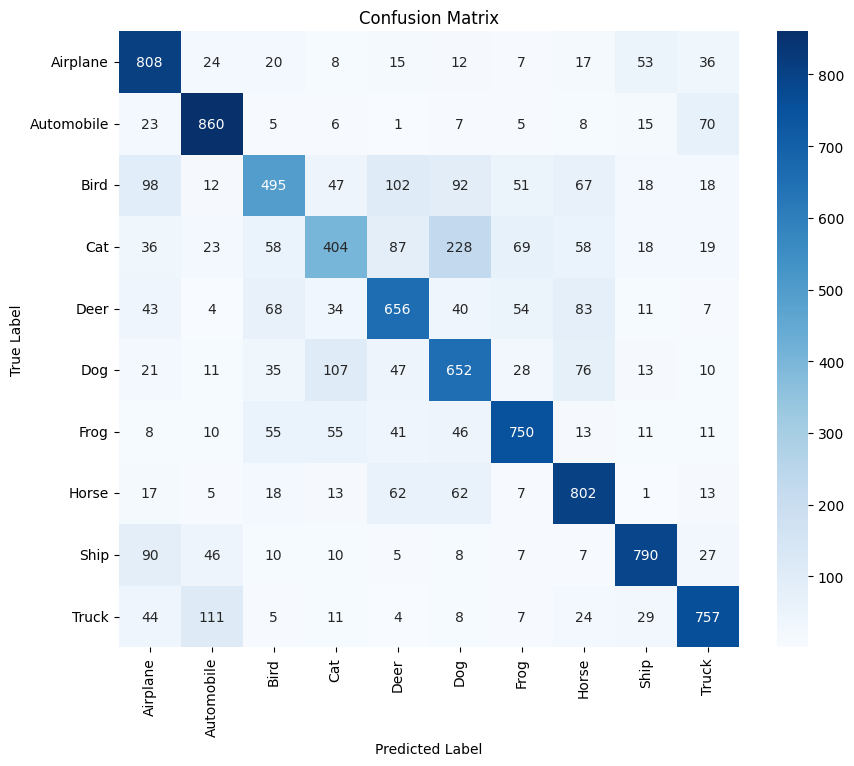

In [27]:
# Confusion Matrix
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.eps", format="eps", bbox_inches="tight")
plt.show()

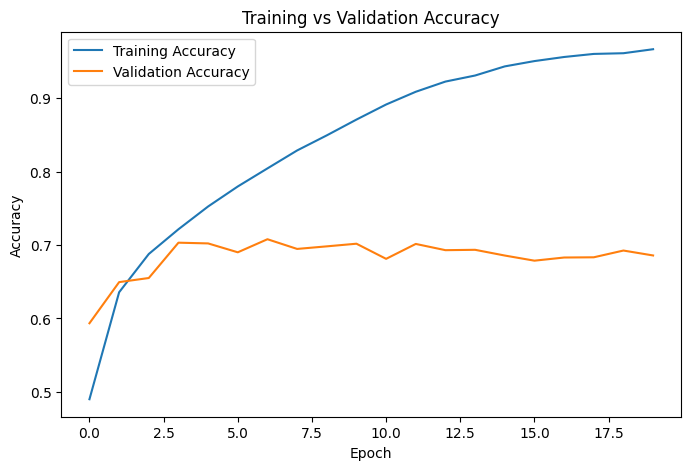

In [28]:
# Training and Validation Accuracy
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.savefig("training_validation_accuracy.eps",
            format="eps",
            bbox_inches="tight")
plt.show()

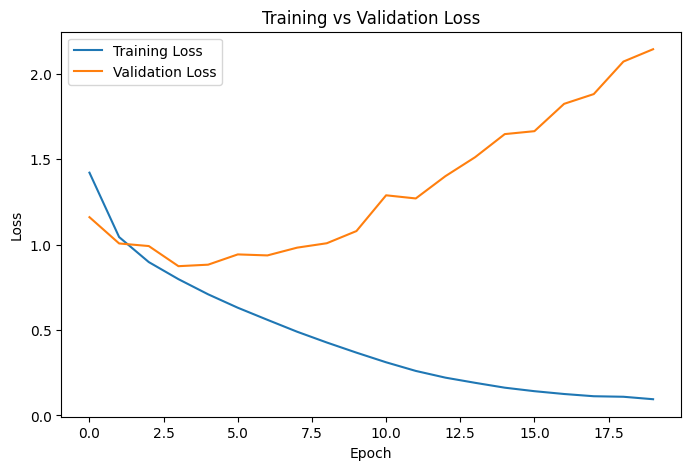

In [29]:
# Training and Validation Loss
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.savefig("training_validation_loss.eps",
            format="eps",
            bbox_inches="tight")
plt.show()

# Results

In [30]:
# Record the required results dynamically
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(true_classes, predicted_classes, average='weighted', zero_division=0)
recall = recall_score(true_classes, predicted_classes, average='weighted', zero_division=0)
f1 = f1_score(true_classes, predicted_classes, average='weighted', zero_division=0)

print("Training Accuracy:", training_accuracy)
print("Testing Accuracy :", test_accuracy)
print("Precision        :", precision)
print("Recall           :", recall)
print("F1-score         :", f1)
print("Number of Parameters:", model.count_params())


Training Accuracy: 0.9666249752044678
Testing Accuracy : 0.6973999738693237
Precision        : 0.6951932197964467
Recall           : 0.6974
F1-score         : 0.6922057868507405
Number of Parameters: 545098


# Additional Exercises

## Max Pooling VS Average Pooling



Max Pooling Accuracy    : 0.6391000151634216
Average Pooling Accuracy: 0.5968999862670898


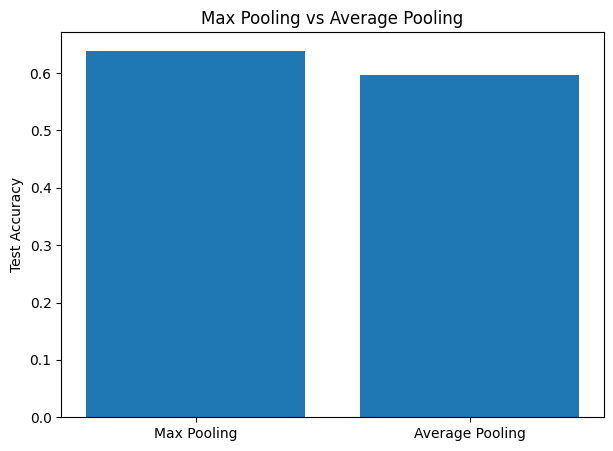

In [31]:
# Pooling comparison result
print("Max Pooling Accuracy    :", max_accuracy)
print("Average Pooling Accuracy:", average_accuracy)

plt.figure(figsize=(7, 5))
plt.bar(["Max Pooling", "Average Pooling"], [max_accuracy, average_accuracy])
plt.ylabel("Test Accuracy")
plt.title("Max Pooling vs Average Pooling")
plt.savefig(
    "max_vs_average_pooling.eps",
    format="eps",
    bbox_inches="tight"
)
plt.show()


## 16 Filters vs 64 Filters

In [36]:
# Compare a CNN using 16 filters with one using 64 filters.
# Ten epochs are used here because this is a comparison experiment.
import time

def build_filter_comparison_model(num_filters):
    comparison_model = Sequential([
        Conv2D(
            filters=num_filters,
            kernel_size=(3, 3),
            activation='relu',
            padding='same',
            input_shape=(32, 32, 3)
        ),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation='relu',
            padding='same'
        ),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])

    comparison_model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return comparison_model

filter_counts = [16, 64]
filter_results = {}

for num_filters in filter_counts:
    comparison_model = build_filter_comparison_model(num_filters)

    start_time = time.perf_counter()
    comparison_history = comparison_model.fit(
        x_train,
        y_train_encoded,
        epochs=10,
        batch_size=32,
        validation_split=0.2,
        verbose=1
    )
    training_time = time.perf_counter() - start_time

    comparison_loss, comparison_accuracy = comparison_model.evaluate(
        x_test,
        y_test_encoded,
        verbose=0
    )

    filter_results[num_filters] = {
        'model': comparison_model,
        'history': comparison_history,
        'test_loss': comparison_loss,
        'test_accuracy': comparison_accuracy,
        'training_time': training_time,
        'parameters': comparison_model.count_params()
    }

for num_filters in filter_counts:
    result = filter_results[num_filters]
    print("Filters:", num_filters)
    print("Test Accuracy:", result['test_accuracy'])
    print("Training Time (seconds):", result['training_time'])
    print("Number of Parameters:", result['parameters'])
    print()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4940 - loss: 1.4161 - val_accuracy: 0.5920 - val_loss: 1.1451
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6319 - loss: 1.0532 - val_accuracy: 0.6333 - val_loss: 1.0362
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6884 - loss: 0.8981 - val_accuracy: 0.6703 - val_loss: 0.9468
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7236 - loss: 0.7874 - val_accuracy: 0.6714 - val_loss: 0.9465
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7552 - loss: 0.6993 - val_accuracy: 0.6963 - val_loss: 0.9093
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7882 - loss: 0.6115 - val_accuracy: 0.7002 - val_loss: 0.8931
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8153 - loss: 0.5296 - val_accuracy: 0.7107 - val_loss: 0.8969
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8436 - loss: 0.4489 - 

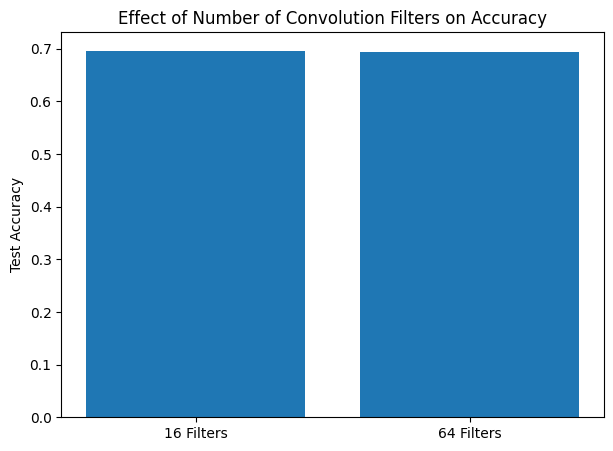

In [37]:
# Plot accuracy comparison for the filter-count experiment
filter_accuracy_values = [filter_results[n]['test_accuracy'] for n in filter_counts]

plt.figure(figsize=(7, 5))
plt.bar([str(n) + " Filters" for n in filter_counts], filter_accuracy_values)
plt.ylabel("Test Accuracy")
plt.title("Effect of Number of Convolution Filters on Accuracy")
plt.show()


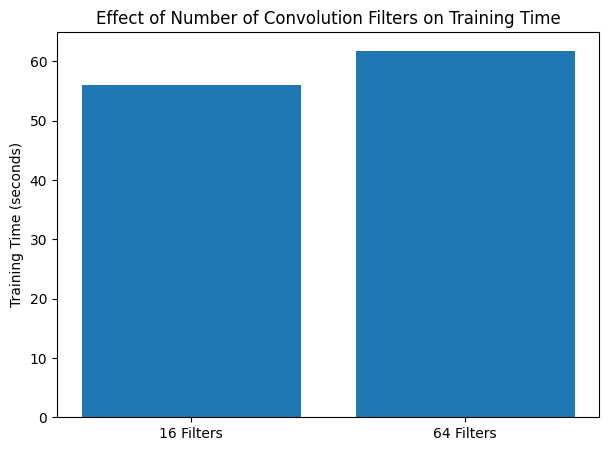

In [38]:
# Plot training-time comparison for the filter-count experiment
filter_time_values = [filter_results[n]['training_time'] for n in filter_counts]

plt.figure(figsize=(7, 5))
plt.bar([str(n) + " Filters" for n in filter_counts], filter_time_values)
plt.ylabel("Training Time (seconds)")
plt.title("Effect of Number of Convolution Filters on Training Time")
plt.show()


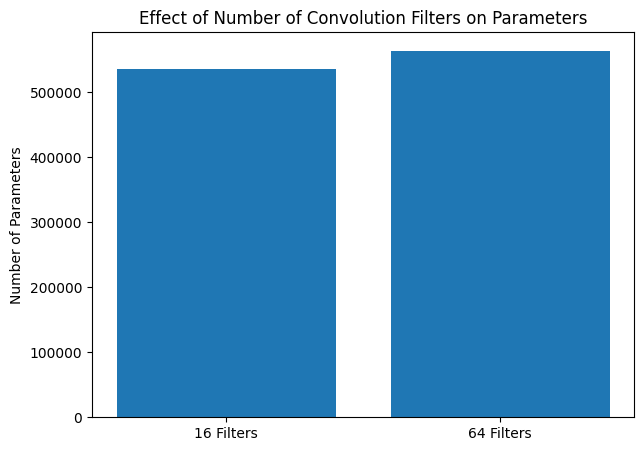

In [39]:
# Plot parameter-count comparison for the filter-count experiment
filter_parameter_values = [filter_results[n]['parameters'] for n in filter_counts]

plt.figure(figsize=(7, 5))
plt.bar([str(n) + " Filters" for n in filter_counts], filter_parameter_values)
plt.ylabel("Number of Parameters")
plt.title("Effect of Number of Convolution Filters on Parameters")
plt.show()
